In [ ]:
# Set up Kaggle API and download dataset using kaggle.json credentials

!pip install kaggle
!mkdir -p ~/.kaggle

from google.colab import files
files.upload()

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d carrie1/ecommerce-data
!unzip ecommerce-data.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
  0% 0.00/7.20M [00:00<?, ?B/s]
100% 7.20M/7.20M [00:00<00:00, 697MB/s]
Archive:  ecommerce-data.zip
  inflating: data.csv                


In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, r2_score

In [ ]:
# Read the CSV file with Latin-1 encoding to prevent errors

df = pd.read_csv("data.csv", encoding='latin-1')

# **Data Overview**

In [ ]:
# Explore the dataset

print('First five rows of the dataset:\n', df.head())
print('Last five rows of the dataset:\n', df.head())

First five rows of the dataset:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
Last five rows of the dataset:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1   

In [ ]:
# Total no. of rows and columns of the dataset
df.shape

(541909, 8)

In [ ]:
# Retrieve the columns names

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
# Statistical Measures of the dataset
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# **Exploratory Data Analysis (EDA)**

**Duplicate & Missing values detection**



In [ ]:
# Missing values in the dataset
missing = df.isna().sum().sort_values(ascending=False)
print(((missing/len(df)) * 100).round(2))


CustomerID        25.16
StockCode          0.00
InvoiceNo          0.00
Description        0.00
Quantity           0.00
InvoiceDate        0.00
UnitPrice          0.00
Country            0.00
IsCancellation     0.00
InvoiceMonth       0.00
InvoiceHour        0.00
dtype: float64


In [ ]:
# Fill up the values with the appropriate values
df['Description'] = df['Description'].fillna('')

# Keep missing CustomerID as NaN
df['CustomerID'] = df['CustomerID'].astype('Int64')

In [ ]:
# Find duplicated values in the dataset
df.duplicated(
    subset=['InvoiceNo', 'StockCode',  'Quantity', 'InvoiceDate', 'UnitPrice']
).sum()

np.int64(5270)

In [ ]:
# Inspection of duplicated transaction lines

dupes = df[df.duplicated(
    subset=['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice'], keep= False
)]
dupes.sort_values(['InvoiceNo', 'StockCode', 'InvoiceDate', 'UnitPrice'])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/2011 13:25,2.95,15110,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838,United Kingdom
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/2011 10:38,2.95,14562,United Kingdom


In [ ]:
# Drop Duplicated Transaction lines

df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice'], keep= 'first',  inplace=True
)
df.sort_values(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice'])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311,United Kingdom
541717,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,12/9/2011 11:58,1.25,17315,United Kingdom


**Cancellation & Returns overview**

In [ ]:
# Identify cancellations and Returns in the dataset
df['IsCancellation'] = df['InvoiceNo'].str.startswith('C')
df['IsCancellation'].value_counts()

,count
IsCancellation,
False,527388
True,9251


In [ ]:
returns = (df['Quantity'] < 0).value_counts()
print((returns/ len(df['Quantity'])* 100).round(2))

Quantity
False    98.03
True      1.97
Name: count, dtype: float64


**Product Analysis**





In [ ]:
# Most frequently purchased products by count
df['Description'].value_counts().head(10)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2357
REGENCY CAKESTAND 3 TIER,2189
JUMBO BAG RED RETROSPOT,2156
PARTY BUNTING,1720
LUNCH BAG RED RETROSPOT,1625
ASSORTED COLOUR BIRD ORNAMENT,1488
SET OF 3 CAKE TINS PANTRY DESIGN,1465
,1454
PACK OF 72 RETROSPOT CAKE CASES,1367


<Axes: title={'center': 'Top 10 products'}, ylabel='Description'>

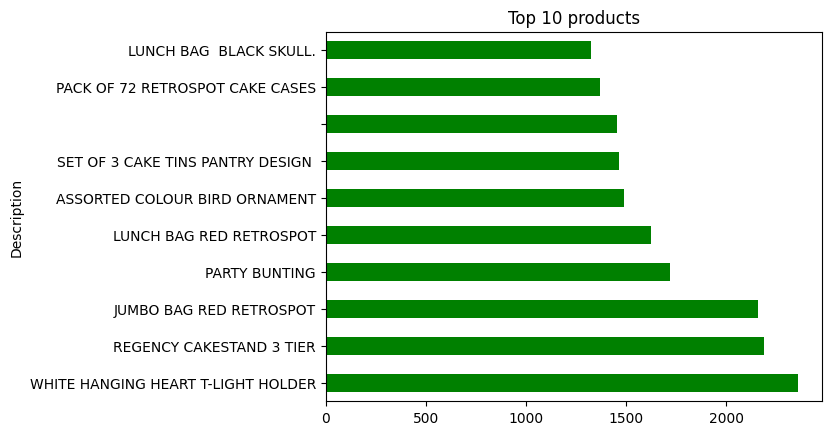

In [ ]:
# Bar chart of Top 10 frequently purchased products
df['Description'].value_counts().head(10).plot(kind = 'barh', color = 'green', title= 'Top 10 products')

In [ ]:
# Most frequently returned products by count
df[df['Quantity'] < 0]['Description'].value_counts().head(10)

,count
Description,
,862
Manual,244
REGENCY CAKESTAND 3 TIER,180
POSTAGE,126
check,120
JAM MAKING SET WITH JARS,87
Discount,77
SET OF 3 CAKE TINS PANTRY DESIGN,73
SAMPLES,60


<Axes: title={'center': 'Returns v/s purchases'}, ylabel='Quantity'>

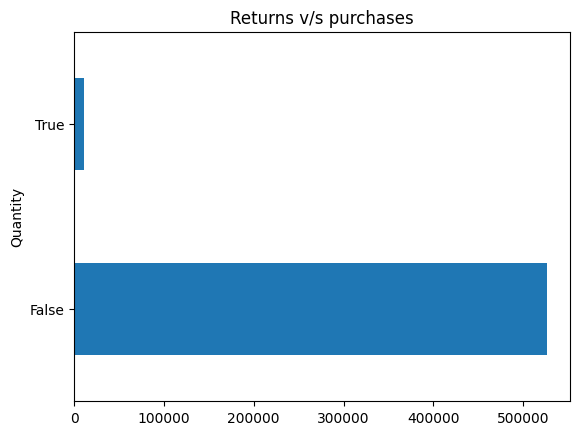

In [ ]:
# Bar chart of returns v/s normal purchases

df['Quantity'].lt(0).value_counts().plot(kind = 'barh', title = 'Returns v/s purchases')

**Transactions & Time-based trends**

In [ ]:
# Total transactions per customer
df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending = False).head(10)

,InvoiceNo
CustomerID,
14911,248
12748,224
17841,169
14606,128
15311,118
13089,118
12971,89
14527,86
13408,81


In [ ]:
# Convert InvoiceDate to Date-time

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Sorting out the Monthly trends

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['InvoiceMonth'].value_counts().sort_index()

,count
InvoiceMonth,
2010-12,41981
2011-01,34900
2011-02,27479
2011-03,36439
2011-04,29701
2011-05,36781
2011-06,36609
2011-07,39267
2011-08,35064


<Axes: title={'center': 'Monthly Transactions'}, xlabel='InvoiceMonth'>

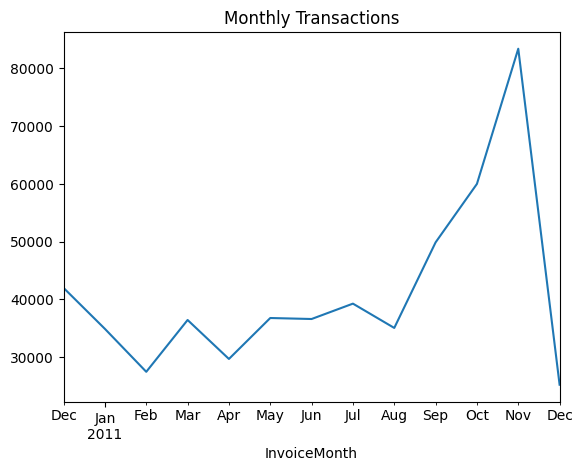

In [ ]:
df['InvoiceMonth'].value_counts().sort_index().plot(kind='line', title='Monthly Transactions')


In [ ]:
# Counting the Hourly trends
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceHour'].value_counts().sort_index()

,count
InvoiceHour,
6,41
7,383
8,8906
9,34314
10,48808
11,56948
12,77573
13,71246
14,66572


<Axes: title={'center': 'Hourly Transactions'}, xlabel='InvoiceHour'>

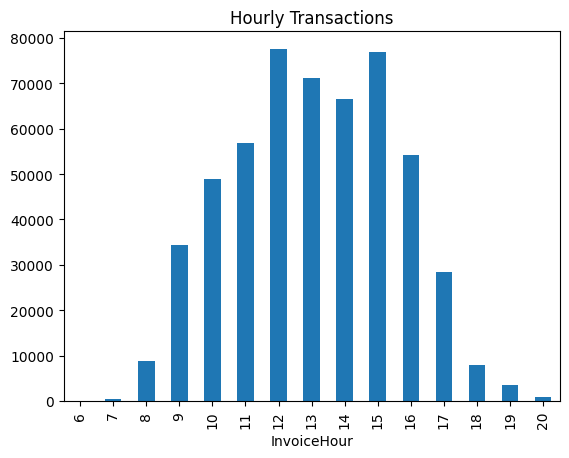

In [ ]:
df['InvoiceHour'].value_counts().sort_index().plot(kind='bar', title='Hourly Transactions')

**Customer & Geography Overview**

In [ ]:
# Total no. of customers
df['CustomerID'].nunique()

4372

In [ ]:
# Retrieve the Top 10 countries by transaction count
df['Country'].value_counts().head(10)


,count
Country,
United Kingdom,490298
Germany,9480
France,8541
EIRE,8184
Spain,2528
Netherlands,2371
Belgium,2069
Switzerland,1994
Portugal,1510


<Axes: title={'center': 'Top Countries by Transactions'}, xlabel='Country'>

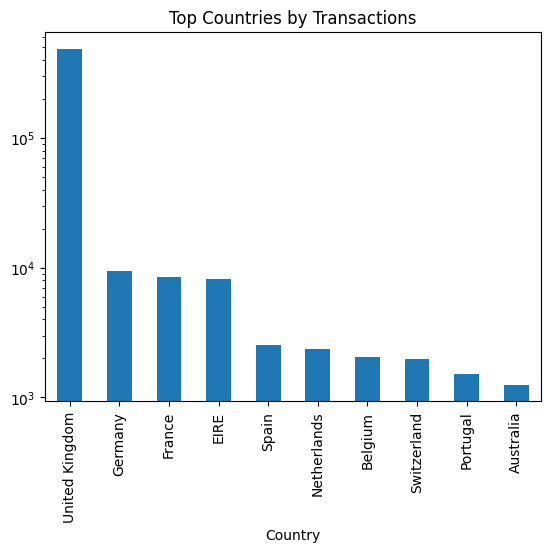

In [ ]:
df['Country'].value_counts().head(10).plot(kind='bar', title='Top Countries by Transactions',logy=True)


# **RFM**

In [ ]:
df_model = df.copy()

In [ ]:
# Remove cancellations, returns, and orders without customer id

df_model = df_model[~df_model['InvoiceNo'].str.startswith('C')]

df_model = df_model[df_model['Quantity'] > 0]

df_model = df_model.dropna(subset=['CustomerID'])

In [ ]:
# Convert InvoiceDate to Date-time
df_model['InvoiceDate'] = pd.to_datetime(df_model['InvoiceDate'], errors='coerce')


# Drop Duplicated Rows
df_model = df_model.drop_duplicates(
    subset=['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice']
)


In [ ]:
df_model.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,InvoiceMonth,InvoiceHour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,2010-12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010-12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,2010-12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010-12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010-12,8


In [ ]:
# Total Monetary Value of each customer

df_model['TotalPrice'] = df_model['Quantity'] * df_model['UnitPrice']

# Snapshot date

snapshot_date = df_model['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM analysis

rfm = df_model.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo' : 'nunique',
    'TotalPrice' : 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']



In [ ]:
# RFM scores

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_Score'] = (
    pd.qcut(rfm['Frequency'], 4, duplicates='drop')
      .cat.codes + 1
)

rfm['M_Score'] = (
    pd.qcut(rfm['Monetary'], 4, duplicates='drop')
      .cat.codes + 1
)

rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,4,6
1,12347,2,7,4310.00,4,3,4,11
2,12348,75,4,1797.24,2,2,4,8
3,12349,19,1,1757.55,3,1,4,8
4,12350,310,1,334.40,1,1,2,4


In [ ]:
# RFM segmentation

def segment_customers(row):
  if row['RFM_Score'] >= 10:
    return 'Champions'
  elif row['RFM_Score'] >= 8:
    return 'Loyal'
  elif row['RFM_Score'] >= 6:
    return 'Potential'
  elif row['RFM_Score'] >= 4:
    return 'At risk'
  else:
    return 'Lost'


In [ ]:
rfm['Segment'] = rfm.apply(segment_customers, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
At risk,1151
Potential,1062
Loyal,829
Champions,796
Lost,501


In [ ]:
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At risk,140.100782,1.422242,385.258906
Champions,12.868090,12.790201,7228.356319
Lost,261.642715,1.121756,169.279541
Loyal,36.034982,4.463209,1917.038783
Potential,64.954802,2.312618,956.137676


In [ ]:
segment_clv = rfm.groupby('Segment')['Monetary'].mean().round(2)
print(segment_clv)

Segment
At risk       385.26
Champions    7228.36
Lost          169.28
Loyal        1917.04
Potential     956.14
Name: Monetary, dtype: float64


# **Machine Learning**





In [ ]:
# Supervised ML classification algorithm

X = rfm[['Recency', 'Frequency', 'Monetary' ]]
y = rfm['Segment']

# Encode labels using Labelencoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train and Test the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size= 0.2, random_state = 42)

# RandomForest Classfication Model
model = RandomForestClassifier(random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_))


              precision    recall  f1-score   support

     At risk       1.00      1.00      1.00       223
   Champions       0.99      1.00      1.00       167
        Lost       1.00      1.00      1.00        95
       Loyal       1.00      0.99      0.99       182
   Potential       0.99      1.00      1.00       201

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [ ]:
# Predicting Segments for all customers
rfm['Predicted_Segment'] = encoder.inverse_transform(model.predict(X))

#  Map CLV from segment averages
rfm['Predicted_CLV'] = rfm['Predict_Segment'].map(segment_clv)


rfm[['CustomerID', 'Predicted_Segment', 'Predicted_CLV']].head()

,CustomerID,Predicted_Segment,Predicted_CLV
0,12346,Potential,956.14
1,12347,Champions,7228.36
2,12348,Loyal,1917.04
3,12349,Loyal,1917.04
4,12350,At risk,385.26
